Данные о симуляции в OpenFoam: \
X = [0,1]\
Y = [0,2] \
Z = [0, 0.01] \
160 ячеек по X, 320 по Y, 1 по Z



In [1]:
import math
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# CSVs:
# - data_points_phi.csv: columns [x, y, phi, t]
# - collocation.csv:  columns [x, y, t]
DATA_CSV = "datasets/data_points_phi.csv"
PHYS_CSV = "datasets/collocation.csv"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32


In [2]:
# Training
LR = 1e-3
PRETRAIN_EPOCHS = 200
FULL_TRAIN_EPOCHS = 1000

BATCH_DATA = 8192
# 6144 covers the physics dataset almost exactly over one full-stage epoch
BATCH_PHYS = 6144
NUM_WORKERS = 0

LAMBDA_DATA = 20.0

PRETRAIN_CKPT_PATH = "checkpoints/model_pretrain.pt"
FULL_CKPT_PATH = "checkpoints/model_full.pt"

# Separate sharpness for supervised pretrain and full PINN stage
S_PRETRAIN = 5.0
S_FULL = 80.0


In [3]:
# =========================
# PHYSICAL DOMAIN (no normalization)
# =========================
# These bounds are used only for the boundary-condition ansatz (sin() factors).
X_MIN, X_MAX = 0.0, 1.0
Y_MIN, Y_MAX = 0.0, 2.0

# Time bounds are not used for scaling anymore; keep for reference/checks.
T_MIN, T_MAX = 0.0, 3.002

g_x = 0.0
g_y = 9.80

# =========================
# FLUID PROPERTIES
# =========================
# phi = +1 liquid, phi = -1 gas
rho_l = 1000.0
rho_g = 100.0

# mu - dynamic viscosity
mu_l = 10.0
mu_g = 1.0

# surface tension
sigma = 24.5
EPS_NORM = 1e-6  # for normals


In [4]:
class DataPoints(Dataset):
    """Supervised data points: (x,y,t) -> phi."""
    def __init__(self, csv_path: str):
        df = pd.read_csv(csv_path)
        for c in ["x", "y", "t", "phi"]:
            if c not in df.columns:
                raise ValueError(f"Missing column '{c}' in {csv_path}. Columns: {df.columns}")
        self.xyt = df[["x", "y", "t"]].to_numpy(dtype=np.float32)
        self.phi = df["phi"].to_numpy(dtype=np.float32)[:, None]

    def __len__(self):
        return self.xyt.shape[0]

    def __getitem__(self, idx):
        return self.xyt[idx], self.phi[idx]


class PhysicsPoints(Dataset):
    """Collocation points for PDE residuals: (x,y,t)."""
    def __init__(self, csv_path: str):
        df = pd.read_csv(csv_path)
        for c in ["x", "y", "t"]:
            if c not in df.columns:
                raise ValueError(f"Missing column '{c}' in {csv_path}. Columns: {df.columns}")
        self.xyt = df[["x", "y", "t"]].to_numpy(dtype=np.float32)

    def __len__(self):
        return self.xyt.shape[0]

    def __getitem__(self, idx):
        return self.xyt[idx]


class AdaptiveSwish(nn.Module):
    """swish_beta(x) = x * sigmoid(beta * x), beta is learnable (scalar)."""
    def __init__(self, init_beta: float = 1.0):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor(float(init_beta)))

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)


class MLP(nn.Module):
    def __init__(self, in_dim=3, out_dim=4, hidden=100, depth=6):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), AdaptiveSwish(1.0)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), AdaptiveSwish(1.0)]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xyt):
        return self.net(xyt)


# =========================
# Physics: mixture laws
# =========================

def mixture_rho(phi: torch.Tensor) -> torch.Tensor:
    return 0.5 * ((1.0 + phi) * rho_l + (1.0 - phi) * rho_g)

def mixture_mu(phi: torch.Tensor) -> torch.Tensor:
    return 0.5 * ((1.0 + phi) * mu_l + (1.0 - phi) * mu_g)


# =========================
# Autodiff helpers
# =========================

def grad(outputs: torch.Tensor, inputs: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]


# =========================
# Forward + hard BC as in paper (computed on physical x,y)
# =========================

def model_fields(model: nn.Module, xyt: torch.Tensor):
    """
    xyt: (N,3) in PHYSICAL coordinates.
    returns: u, v, p, alpha_sdf
    """
    out = model(xyt)
    u_raw = out[:, 0:1]
    v_raw = out[:, 1:2]
    p = out[:, 2:3]
    alpha = out[:, 3:4]

    # Pressure gauge: remove mean to fix constant ambiguity
    p = p - p.mean()

    # Hard no-slip BC via ansatz (x in [0,1], y in [0,2]):
    # l_u = sin(pi x) * sin(pi y/2)
    # l_v = sin(pi y/2)
    x = xyt[:, 0:1]
    y = xyt[:, 1:2]
    l_u = torch.sin(math.pi * x) * torch.sin(math.pi * y / 2.0)
    l_v = torch.sin(math.pi * y / 2.0)

    u = l_u * u_raw
    v = l_v * v_raw

    return u, v, p, alpha


In [5]:
def get_phys_weights(epoch):
    """
    Returns (w_div, w_adv, w_mom, w_eik, lambda_phys_global)
    for the full PINN stage after supervised pretraining.
    """
    if epoch <= 150:
        return 1.0, 1.0, 0.0, 0.0, 0.05

    if epoch <= 500:
        return 1.0, 1.0, 0.5, 0.0, 0.10

    if epoch <= 800:
        return 1.0, 1.0, 1.0, 0.0, 0.20

    return 1.0, 1.0, 1.0, 0.1, 0.30


In [6]:
torch.manual_seed(0)
np.random.seed(0)
os.makedirs("checkpoints", exist_ok=True)

data_ds = DataPoints(DATA_CSV)
phys_ds = PhysicsPoints(PHYS_CSV)

data_loader = DataLoader(data_ds, batch_size=BATCH_DATA, shuffle=True, drop_last=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=False)
phys_loader = DataLoader(phys_ds, batch_size=BATCH_PHYS, shuffle=True, drop_last=True, num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=False)

def build_model():
    return MLP(in_dim=3, out_dim=4, hidden=100, depth=6).to(DEVICE).to(DTYPE)

def build_optimizer(model: nn.Module):
    return torch.optim.Adam(model.parameters(), lr=LR)

def load_checkpoint_weights(model: nn.Module, ckpt_path: str):
    state = torch.load(ckpt_path, map_location=DEVICE)
    if isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    elif isinstance(state, dict):
        model.load_state_dict(state)
    else:
        raise ValueError(f"Unexpected checkpoint format: {ckpt_path}")
    return model


In [7]:
def residuals(model: nn.Module, xyt: torch.Tensor, s_val: float):
    """
    Compute residuals at physics points in PHYSICAL coordinates.
    All derivatives are computed w.r.t (x,y,t) directly (no normalization).
    """
    xyt = xyt.requires_grad_(True)

    u, v, p, alpha = model_fields(model, xyt)

    phi = torch.tanh(float(s_val) * alpha)
    delta = 1.0 - phi**2  # = 1 - tanh^2(s alpha)

    # Mixture properties
    rho = mixture_rho(phi)
    mu = mixture_mu(phi)

    # First derivatives (physical)
    u_grad = grad(u, xyt)   # du/dx, du/dy, du/dt
    v_grad = grad(v, xyt)
    p_grad = grad(p, xyt)
    a_grad = grad(alpha, xyt)

    u_x, u_y, u_t = u_grad[:, 0:1], u_grad[:, 1:2], u_grad[:, 2:3]
    v_x, v_y, v_t = v_grad[:, 0:1], v_grad[:, 1:2], v_grad[:, 2:3]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]
    a_x, a_y, a_t = a_grad[:, 0:1], a_grad[:, 1:2], a_grad[:, 2:3]

    # Divergence residual
    r_div = u_x + v_y

    # Level-set transport residual
    r_adv = a_t + u * a_x + v * a_y

    # Eikonal residual (SDF constraint)
    grad_a_norm = torch.sqrt(a_x**2 + a_y**2 + 1e-12)
    r_eik = grad_a_norm - 1.0

    n_x = a_x / (grad_a_norm + EPS_NORM)
    n_y = a_y / (grad_a_norm + EPS_NORM)

    n_x_grad = grad(n_x, xyt)
    n_y_grad = grad(n_y, xyt)

    dnxx_dx = n_x_grad[:, 0:1]
    dnyy_dy = n_y_grad[:, 1:2]

    kappa = dnxx_dx + dnyy_dy

    f_st_x = sigma * kappa * n_x * delta
    f_st_y = sigma * kappa * n_y * delta

    Dxx = u_x
    Dyy = v_y
    Dxy = 0.5 * (u_y + v_x)

    term_xx = 2.0 * mu * Dxx
    term_xy = 2.0 * mu * Dxy
    term_yy = 2.0 * mu * Dyy

    term_xx_grad = grad(term_xx, xyt)
    term_xy_grad = grad(term_xy, xyt)
    term_yy_grad = grad(term_yy, xyt)

    visc_x = term_xx_grad[:, 0:1] + term_xy_grad[:, 1:2]
    visc_y = term_xy_grad[:, 0:1] + term_yy_grad[:, 1:2]

    r_mom_u = rho * (u_t + u * u_x + v * u_y) + p_x - visc_x - rho * g_x - f_st_x
    r_mom_v = rho * (v_t + u * v_x + v * v_y) + p_y - visc_y - rho * g_y - f_st_y

    return {
        "r_div": r_div,
        "r_adv": r_adv,
        "r_eik": r_eik,
        "r_mom_u": r_mom_u,
        "r_mom_v": r_mom_v,
        "phi": phi,
        "alpha": alpha,
        "u": u,
        "v": v,
        "p": p,
    }


In [8]:
from itertools import cycle
from tqdm.auto import tqdm
import torch

s_pretrain = S_PRETRAIN
s_full = S_FULL
s_pretrain_tensor = torch.tensor(s_pretrain, device=DEVICE, dtype=DTYPE)
s_full_tensor = torch.tensor(s_full, device=DEVICE, dtype=DTYPE)

# -------- EMA settings for the full PINN stage --------
EMA_BETA = 0.99
EMA_EPS = 1e-8
EMA_WARMUP_STEPS = 200

def make_pretrain_history():
    return {
        "epoch": [],
        "loss": [],
        "loss_data": [],
        "s": [],
    }

def make_full_history():
    return {
        "epoch": [],
        "loss": [],
        "loss_data": [],
        "loss_phys": [],
        "s": [],
        "L_div": [],
        "L_adv": [],
        "L_mom": [],
        "L_eik": [],
        "ema_div": [],
        "ema_adv": [],
        "ema_mom": [],
        "ema_eik": [],
    }

def save_checkpoint(model: nn.Module, ckpt_path: str, epoch: int, stage: str):
    torch.save(
        {
            "epoch": epoch,
            "stage": stage,
            "model_state_dict": model.state_dict(),
        },
        ckpt_path,
    )
    print(f"Saved checkpoint: {ckpt_path}")

def train_pretrain(model: nn.Module, opt: torch.optim.Optimizer, epochs: int):
    history = make_pretrain_history()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_loss_data = 0.0

        with tqdm(
            data_loader,
            desc=f"Pretrain {epoch}/{epochs}",
            total=len(data_loader),
            dynamic_ncols=True,
            leave=False,
        ) as pbar:
            for (xyt_d_np, phi_np) in pbar:
                xyt_d = xyt_d_np.to(DEVICE, dtype=DTYPE)
                phi_true = phi_np.to(DEVICE, dtype=DTYPE)

                _, _, _, alpha_d = model_fields(model, xyt_d)
                phi_pred = torch.tanh(s_pretrain_tensor * alpha_d)
                loss_data = torch.mean((phi_pred - phi_true) ** 2)
                loss = LAMBDA_DATA * loss_data

                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

                running_loss += float(loss.item())
                running_loss_data += float(loss_data.item())

                pbar.set_postfix(
                    loss=f"{loss.item():.4e}",
                    loss_data=f"{loss_data.item():.4e}",
                )

        n_batches = len(data_loader)
        history["epoch"].append(epoch)
        history["loss"].append(running_loss / n_batches)
        history["loss_data"].append(running_loss_data / n_batches)
        history["s"].append(s_pretrain)

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"pretrain_epoch={epoch:5d} "
                f"loss={history['loss'][-1]:.4e} "
                f"loss_data={history['loss_data'][-1]:.4e}"
            )

    save_checkpoint(model, PRETRAIN_CKPT_PATH, epochs, stage="pretrain")
    return history


In [ ]:
model = build_model()
opt = build_optimizer(model)
pretrain_history = train_pretrain(model, opt, PRETRAIN_EPOCHS)


In [ ]:
def train_full(model: nn.Module, opt: torch.optim.Optimizer, epochs: int):
    history = make_full_history()
    ema = {"div": None, "adv": None, "mom": None, "eik": None}
    ema_steps = 0

    def ema_update(key: str, value: torch.Tensor):
        nonlocal ema_steps
        v = value.detach()
        if ema[key] is None:
            ema[key] = v
        else:
            ema[key] = EMA_BETA * ema[key] + (1.0 - EMA_BETA) * v

    def ema_scale(key: str):
        if ema[key] is None:
            raise RuntimeError(f"EMA for {key} is not initialized")
        if ema_steps < EMA_WARMUP_STEPS:
            return (ema[key] + EMA_EPS).detach() + 1.0
        return (ema[key] + EMA_EPS).detach()

    n_steps = max(len(data_loader), len(phys_loader))

    for epoch in range(1, epochs + 1):
        model.train()
        running = {
            "loss": 0.0,
            "loss_data": 0.0,
            "loss_phys": 0.0,
            "L_div": 0.0,
            "L_adv": 0.0,
            "L_mom": 0.0,
            "L_eik": 0.0,
        }
        data_iter = cycle(data_loader)
        phys_iter = cycle(phys_loader)

        with tqdm(
            range(n_steps),
            desc=f"Full train {epoch}/{epochs}",
            total=n_steps,
            dynamic_ncols=True,
            leave=False,
        ) as pbar:
            for _ in pbar:
                xyt_d_np, phi_np = next(data_iter)
                xyt_p_np = next(phys_iter)

                xyt_d = xyt_d_np.to(DEVICE, dtype=DTYPE)
                phi_true = phi_np.to(DEVICE, dtype=DTYPE)
                xyt_p = xyt_p_np.to(DEVICE, dtype=DTYPE)

                _, _, _, alpha_d = model_fields(model, xyt_d)
                phi_pred = torch.tanh(s_full_tensor * alpha_d)
                loss_data = torch.mean((phi_pred - phi_true) ** 2)

                res = residuals(model, xyt_p, s_val=s_full)
                L_div = torch.mean(res["r_div"] ** 2)
                L_adv = torch.mean(res["r_adv"] ** 2)
                L_eik = torch.mean(res["r_eik"] ** 2)
                L_mom = torch.mean(res["r_mom_u"] ** 2) + torch.mean(res["r_mom_v"] ** 2)

                ema_update("div", L_div)
                ema_update("adv", L_adv)
                ema_update("mom", L_mom)
                ema_update("eik", L_eik)
                ema_steps += 1

                L_div_n = L_div / ema_scale("div")
                L_adv_n = L_adv / ema_scale("adv")
                L_mom_n = L_mom / ema_scale("mom")
                L_eik_n = L_eik / ema_scale("eik")

                w_div, w_adv, w_mom, w_eik, lam_phys = get_phys_weights(epoch)
                loss_phys = w_div * L_div_n + w_adv * L_adv_n + w_mom * L_mom_n + w_eik * L_eik_n
                loss = LAMBDA_DATA * loss_data + lam_phys * loss_phys

                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

                running["loss"] += float(loss.item())
                running["loss_data"] += float(loss_data.item())
                running["loss_phys"] += float(loss_phys.item())
                running["L_div"] += float(L_div.item())
                running["L_adv"] += float(L_adv.item())
                running["L_mom"] += float(L_mom.item())
                running["L_eik"] += float(L_eik.item())

                pbar.set_postfix(
                    loss=f"{loss.item():.4e}",
                    loss_data=f"{loss_data.item():.4e}",
                    lambda_phys=f"{lam_phys:.2e}",
                    div=f"{L_div.item():.2e}",
                    adv=f"{L_adv.item():.2e}",
                    mom=f"{L_mom.item():.2e}",
                    eik=f"{L_eik.item():.2e}",
                )

        history["epoch"].append(epoch)
        history["loss"].append(running["loss"] / n_steps)
        history["loss_data"].append(running["loss_data"] / n_steps)
        history["loss_phys"].append(running["loss_phys"] / n_steps)
        history["s"].append(s_full)
        history["L_div"].append(running["L_div"] / n_steps)
        history["L_adv"].append(running["L_adv"] / n_steps)
        history["L_mom"].append(running["L_mom"] / n_steps)
        history["L_eik"].append(running["L_eik"] / n_steps)
        history["ema_div"].append(float(ema["div"].item()))
        history["ema_adv"].append(float(ema["adv"].item()))
        history["ema_mom"].append(float(ema["mom"].item()))
        history["ema_eik"].append(float(ema["eik"].item()))

        if epoch % 25 == 0 or epoch == 1:
            print(
                f"full_epoch={epoch:5d} "
                f"loss={history['loss'][-1]:.4e} "
                f"loss_data={history['loss_data'][-1]:.4e} "
                f"loss_phys={history['loss_phys'][-1]:.4e} "
                f"lambda_phys={get_phys_weights(epoch)[4]:.2e} "
                f"L_div={history['L_div'][-1]:.4e} "
                f"L_adv={history['L_adv'][-1]:.4e} "
                f"L_mom={history['L_mom'][-1]:.4e} "
                f"L_eik={history['L_eik'][-1]:.4e} "
                f"ema_div={history['ema_div'][-1]:.4e} "
                f"ema_adv={history['ema_adv'][-1]:.4e} "
                f"ema_mom={history['ema_mom'][-1]:.4e} "
                f"ema_eik={history['ema_eik'][-1]:.4e} "
            )

    save_checkpoint(model, FULL_CKPT_PATH, epochs, stage="full")
    return history


In [14]:
model = build_model()
load_checkpoint_weights(model, PRETRAIN_CKPT_PATH)
opt = build_optimizer(model)
full_history = train_full(model, opt, FULL_TRAIN_EPOCHS)

# Keep `history` pointing to the second stage for downstream plotting/debug.
history = full_history


Full train 1/1000:   0%|          | 0/49 [00:00<?, ?it/s]

full_epoch=    1 loss=8.0543e+00 loss_data=4.0156e-01 loss_phys=4.6018e-01 lambda_phys=5.00e-02L_div=2.3096e+00 L_adv=2.9076e+01 L_mom=8.6620e+07 L_eik=1.1515e+03 ema_div=7.2735e+00 ema_adv=9.2240e+01 ema_mom=9.0123e+07 ema_eik=1.1194e+03 


Full train 2/1000:   0%|          | 0/49 [00:00<?, ?it/s]

Full train 3/1000:   0%|          | 0/49 [00:00<?, ?it/s]

Full train 4/1000:   0%|          | 0/49 [00:00<?, ?it/s]

...

Full train 210/1000:   0%|          | 0/49 [00:00<?, ?it/s]

Full train 211/1000:   0%|          | 0/49 [00:00<?, ?it/s]

Full train 212/1000:   0%|          | 0/49 [00:00<?, ?it/s]

Full train 213/1000:   0%|          | 0/49 [00:00<?, ?it/s]

KeyboardInterrupt: 

NameError: name 'full_history' is not defined

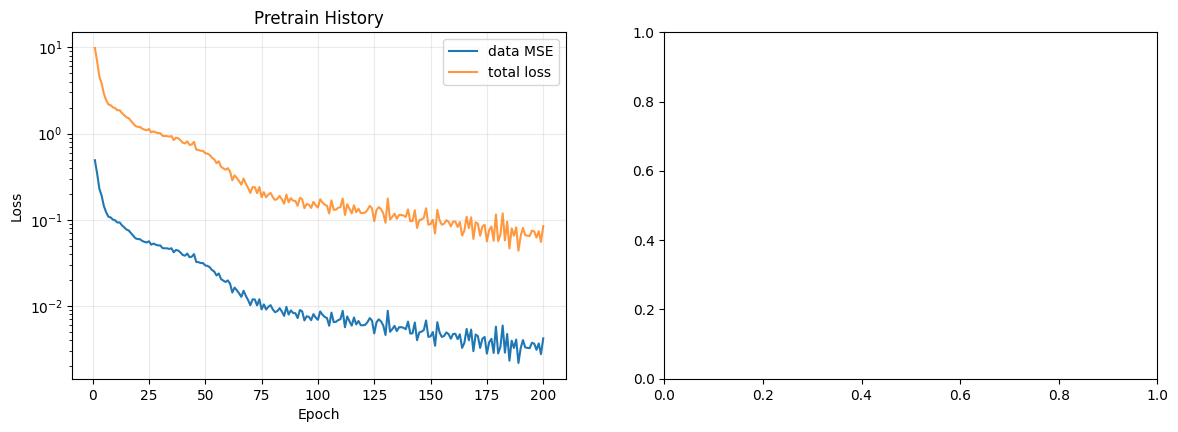

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(pretrain_history["epoch"], pretrain_history["loss_data"], label="data MSE", color="tab:blue")
axes[0].plot(pretrain_history["epoch"], pretrain_history["loss"], label="total loss", color="tab:orange", alpha=0.8)
axes[0].set_title("Pretrain History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(full_history["epoch"], full_history["loss"], label="total loss", color="black")
axes[1].plot(full_history["epoch"], full_history["loss_data"], label="data loss", color="tab:blue")
axes[1].plot(full_history["epoch"], full_history["loss_phys"], label="physics loss", color="tab:red")
axes[1].set_title("Full PINN History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Pretrain checkpoint: {PRETRAIN_CKPT_PATH}")
print(f"Full-training checkpoint: {FULL_CKPT_PATH}")


In [57]:
import torch
import numpy as np

# Choose which stage to inspect: PRETRAIN_CKPT_PATH or FULL_CKPT_PATH.
CKPT_TO_LOAD = PRETRAIN_CKPT_PATH

model = build_model()
load_checkpoint_weights(model, CKPT_TO_LOAD)
model.eval()


MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=100, bias=True)
    (1): AdaptiveSwish()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): AdaptiveSwish()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): AdaptiveSwish()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): AdaptiveSwish()
    (8): Linear(in_features=100, out_features=100, bias=True)
    (9): AdaptiveSwish()
    (10): Linear(in_features=100, out_features=100, bias=True)
    (11): AdaptiveSwish()
    (12): Linear(in_features=100, out_features=4, bias=True)
  )
)

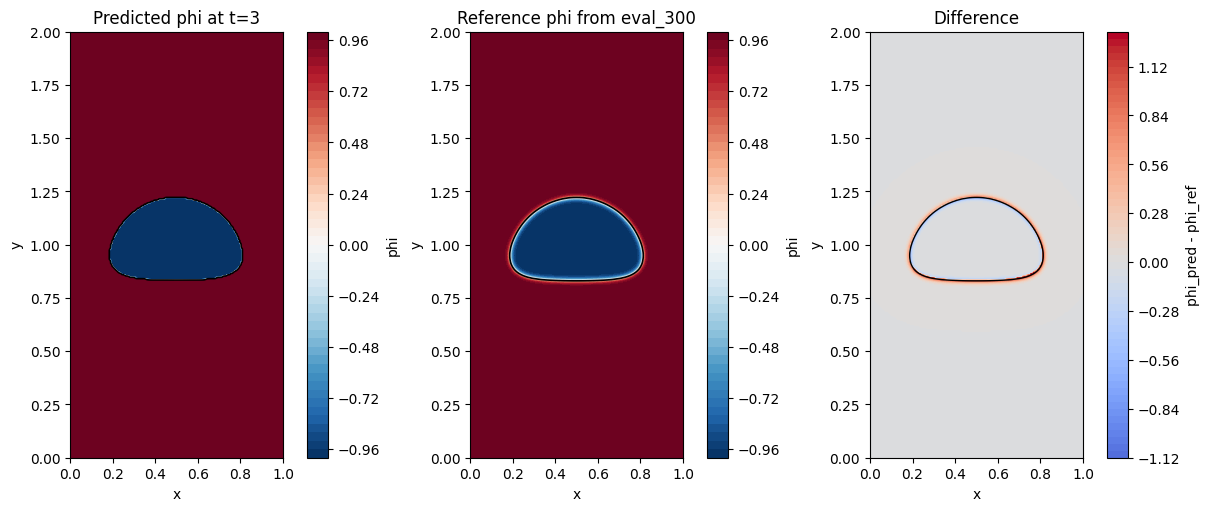

In [33]:
import numpy as np
import matplotlib.pyplot as plt
t_val = 3
eval_path = f"eval/eval_{t_val * 100}.csv"

eval_df = pd.read_csv(eval_path)
eval_df = eval_df[np.isclose(eval_df["Time"].to_numpy(dtype=float), t_val)].copy()
if eval_df.empty:
    raise ValueError(f"No rows with Time={t_val} found in {eval_path}")

phi_ref_df = eval_df.pivot(index="Points:1", columns="Points:0", values="phi").sort_index().sort_index(axis=1)
x_vals = phi_ref_df.columns.to_numpy(dtype=float)
y_vals = phi_ref_df.index.to_numpy(dtype=float)
X_np, Y_np = np.meshgrid(x_vals, y_vals, indexing="xy")
phi_ref = phi_ref_df.to_numpy(dtype=float)

X = torch.as_tensor(X_np, device=DEVICE, dtype=DTYPE)
Y = torch.as_tensor(Y_np, device=DEVICE, dtype=DTYPE)
XYT = torch.stack(
    [X.reshape(-1), Y.reshape(-1), torch.full((X.numel(),), t_val, device=DEVICE, dtype=DTYPE)],
    dim=1,
)

with torch.no_grad():
    out = model(XYT)
    alpha_sdf = out[:, 3]
    phi_pred = np.tanh(S_FULL * alpha_sdf.reshape(len(y_vals), len(x_vals)).detach().cpu().numpy())

phi_diff = phi_pred - phi_ref
diff_lim = np.max(np.abs(phi_diff))
diff_lim = max(diff_lim, 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(12, 5), constrained_layout=True)

cf0 = axes[0].contourf(X_np, Y_np, phi_pred, levels=60, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].contour(X_np, Y_np, phi_pred, levels=[0.0], colors="k", linewidths=1.2)
fig.colorbar(cf0, ax=axes[0], label="phi")
axes[0].set_title(f"Predicted phi at t={t_val}")

cf1 = axes[1].contourf(X_np, Y_np, phi_ref, levels=60, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].contour(X_np, Y_np, phi_ref, levels=[0.0], colors="k", linewidths=1.2)
fig.colorbar(cf1, ax=axes[1], label="phi")
axes[1].set_title(f"Reference phi from eval_{t_val * 100}")

cf2 = axes[2].contourf(X_np, Y_np, phi_diff, levels=60, cmap="coolwarm", vmin=-diff_lim, vmax=diff_lim)
axes[2].contour(X_np, Y_np, phi_ref, levels=[0.0], colors="k", linewidths=1.0)
fig.colorbar(cf2, ax=axes[2], label="phi_pred - phi_ref")
axes[2].set_title("Difference")

for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 2)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")

plt.show()


NameError: name 'full_history' is not defined

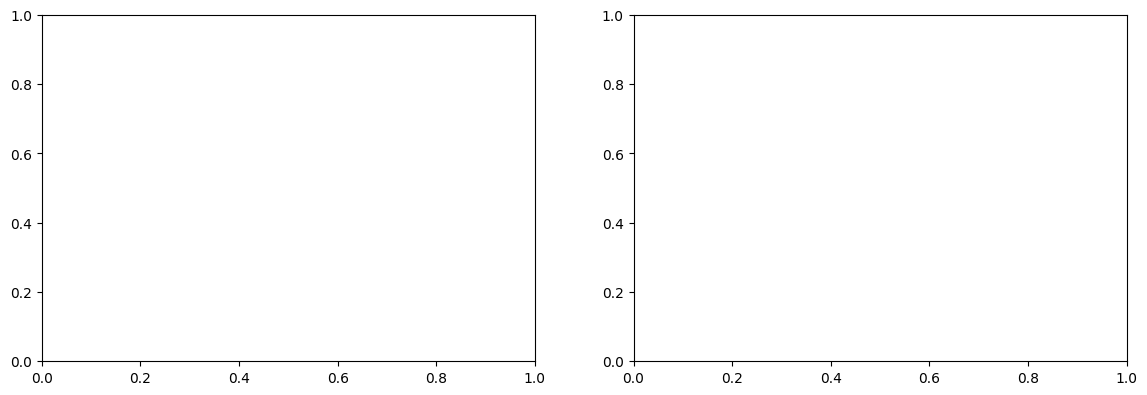

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(full_history["epoch"], full_history["L_div"], label="div")
axes[0].plot(full_history["epoch"], full_history["L_adv"], label="adv")
axes[0].plot(full_history["epoch"], full_history["L_mom"], label="mom")
axes[0].plot(full_history["epoch"], full_history["L_eik"], label="eik")
axes[0].set_title("Raw Physics Terms")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Squared Residual")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].plot(full_history["epoch"], full_history["ema_div"], label="EMA div")
axes[1].plot(full_history["epoch"], full_history["ema_adv"], label="EMA adv")
axes[1].plot(full_history["epoch"], full_history["ema_mom"], label="EMA mom")
axes[1].plot(full_history["epoch"], full_history["ema_eik"], label="EMA eik")
axes[1].set_title("EMA Scales In Full PINN")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("EMA Value")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()
